In [1]:
# 01_EuroSAT_satellite_image_classification.ipynb

# Введение

Первое практическое задание в рамках самостоятельного изучения *PyTorch*

Данная работа направлена на закрепление навыков по следующим темам:

| № | Тема |
| ---- | -------------------------- |
| 1    | Основы PyTorch             |
| 2    | MLP и классификация        |
| 3    | CNN                        |
| 4    | Надежный training pipeline |
| 5    | Fine-Tuning                |
| 6    | Аугментация                |


Данные представлены в датасете [torch.EuroSAT](https://docs.pytorch.org/vision/main/generated/torchvision.datasets.EuroSAT.html)

In [2]:
# Импорты

import os
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, confusion_matrix

import torch
from torch import nn
from torch.utils.data import Subset, DataLoader

from torchvision.datasets import EuroSAT
from torchvision import transforms
from torchvision.transforms import functional as TF

In [3]:
# Constants
RANDOM_SEED = 42

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# 1. EuroSAT - Data Pipeline

## 1.1 Загрузка и осмотр данных

100%|██████████| 94.3M/94.3M [00:01<00:00, 93.4MB/s]


Количество изображений: 27000
Тип изображения: <class 'PIL.Image.Image'>
Размер (ширина, высота) (64, 64)
Цветной режим: RGB
Метка класса: 0


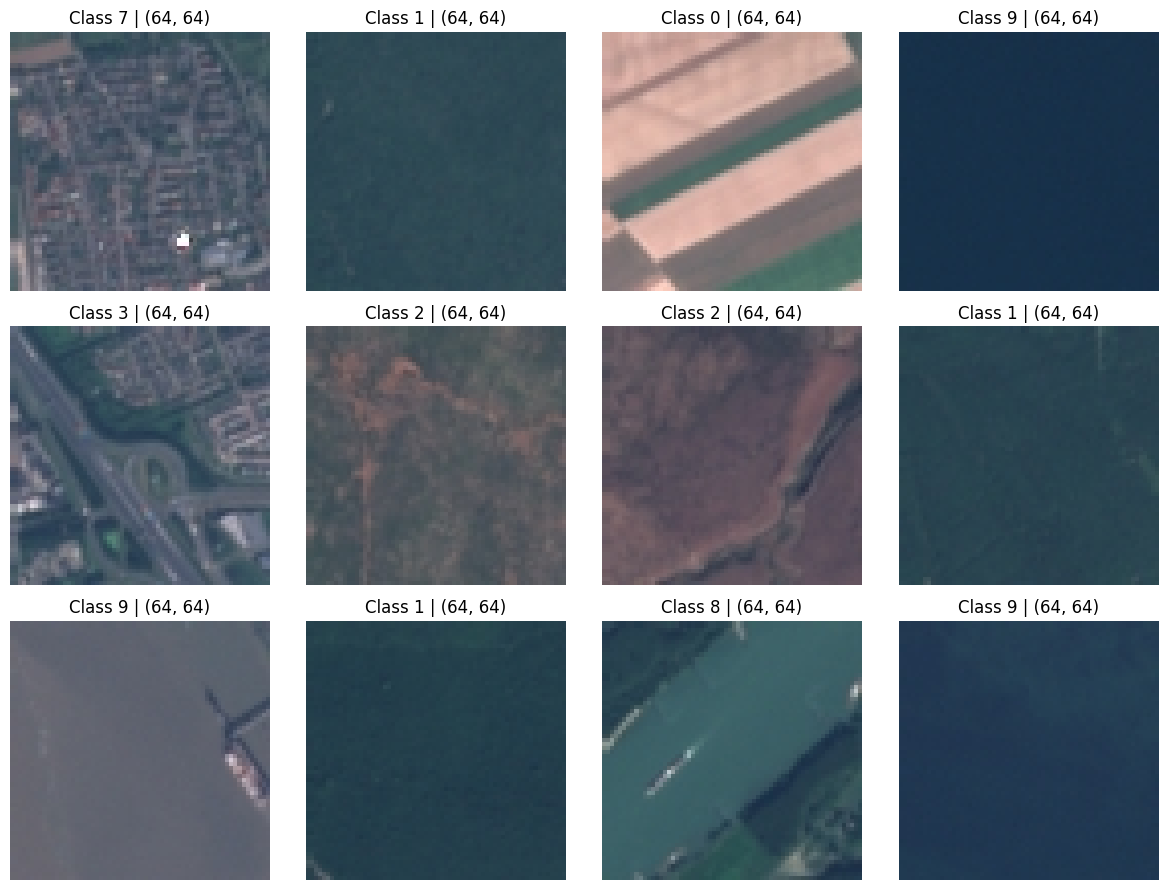

In [4]:
dataset = EuroSAT(
    root='data',
    download=True,
)

print("Количество изображений:", len(dataset))

image, label = dataset[0]

print("Тип изображения:", type(image))
print("Размер (ширина, высота)", image.size)
print("Цветной режим:", image.mode)
print("Метка класса:", label)

indices = random.Random(RANDOM_SEED).sample(range(len(dataset)), 12)

fig, axes = plt.subplots(3, 4, figsize=(12, 9))

for ax, index in zip(axes.flat, indices):
  image, label = dataset[index]

  ax.imshow(image)
  ax.set_title(f"Class {label} | {image.size}")
  ax.axis('off')

plt.tight_layout()
plt.show()


In [5]:
rows = []

for index in range(len(dataset)):
  image, label = dataset[index]

  size = image.size
  rows.append({
      'index': index,
      'label': label,
      'width': size[0],
      'height': size[1],
      'aspect_ratio': size[0] / size[1],
  })

metadata = pd.DataFrame(rows)

print(metadata.head())

print(
    metadata[['width', 'height', 'aspect_ratio']].describe()
)

class_counts = metadata['label'].value_counts().sort_index()

print("Количество классов:", len(class_counts))
print("Минимум изображений в классе:", class_counts.min())
print("Максимум изображений в классе:", class_counts.max())


class_counts.index = dataset.classes
print('\nРаспределение классов')
print(class_counts)

   index  label  width  height  aspect_ratio
0      0      0     64      64           1.0
1      1      0     64      64           1.0
2      2      0     64      64           1.0
3      3      0     64      64           1.0
4      4      0     64      64           1.0
         width   height  aspect_ratio
count  27000.0  27000.0       27000.0
mean      64.0     64.0           1.0
std        0.0      0.0           0.0
min       64.0     64.0           1.0
25%       64.0     64.0           1.0
50%       64.0     64.0           1.0
75%       64.0     64.0           1.0
max       64.0     64.0           1.0
Количество классов: 10
Минимум изображений в классе: 2000
Максимум изображений в классе: 3000

Распределение классов
AnnualCrop              3000
Forest                  3000
HerbaceousVegetation    3000
Highway                 2500
Industrial              2500
Pasture                 2000
PermanentCrop           2500
Residential             3000
River                   2500
SeaLake   

## 1.2 Фиксация train, validation и test

Разделение в пропорции 80/10/10 с использованием стратификации

In [6]:
train_indices, temp_indices = train_test_split(
    metadata["index"].to_numpy(),
    test_size=0.2,
    stratify=metadata["label"].to_numpy(),
    random_state=RANDOM_SEED,
)

val_indices, test_indices = train_test_split(
    temp_indices,
    test_size=0.5,
    stratify=metadata["label"].iloc[temp_indices].to_numpy(),
    random_state=RANDOM_SEED
)

print("Train:", len(train_indices))
print("Validation:", len(val_indices))
print("Test:", len(test_indices))
print(
    "Train/Val overlap:",
    len(set(train_indices) & set(val_indices))
)

print(
    "Train/Test overlap:",
    len(set(train_indices) & set(test_indices))
)

print(
    "Val/Test overlap:",
    len(set(val_indices) & set(test_indices))
)

Train: 21600
Validation: 2700
Test: 2700
Train/Val overlap: 0
Train/Test overlap: 0
Val/Test overlap: 0


Все изображения в датасете имеют одинаковый размер (64, 64), поэтому, на текущем этапе нет нужды в изменении размера

## 1.3 Собираем tensor

In [7]:
basic_transform = transforms.Compose([
    transforms.ToTensor(),
])

image_tensor = basic_transform(image)

print("Shape:", image_tensor.shape)
print("Dtype:", image_tensor.dtype)
print("Range:", image_tensor.min().item(), image_tensor.max().item())

Shape: torch.Size([3, 64, 64])
Dtype: torch.float32
Range: 0.3333333432674408 0.6196078658103943


## 1.4 Создаем обучающую и валидационную части



In [8]:
train_source = EuroSAT(
    root='data',
    download=False,
)

val_source = EuroSAT(
    root='data',
    download=False,
)

test_source = EuroSAT(
    root='data',
    download=False,
)

train_dataset = Subset(train_source, train_indices.tolist())
val_dataset = Subset(val_source, val_indices.tolist())
test_dataset = Subset(test_source, test_indices.tolist())

train_source.transform = basic_transform
val_source.transform = basic_transform
test_source.transform = basic_transform

class_names = train_source.classes

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))
print("Classes:", len(class_names))

Train: 21600
Validation: 2700
Test: 2700
Classes: 10


## 1.5 Собираем батчи

In [9]:
# Функция для создания train_loader
def make_train_loader(dataset, seed):
    generator = torch.Generator()
    generator.manual_seed(seed)

    return DataLoader(
        dataset,
        batch_size=32,
        shuffle=True,
        num_workers=0,
        generator=generator,
    )

In [10]:
seed_everything(RANDOM_SEED)

train_loader = make_train_loader(
    train_dataset,
    RANDOM_SEED
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

images, labels = next(iter(val_loader))

print("Images:", images.shape, images.dtype)
print("Labels:", labels.shape, labels.dtype)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Images: torch.Size([32, 3, 64, 64]) torch.float32
Labels: torch.Size([32]) torch.int64
Train batches: 675
Validation batches: 85
Test batches: 85


Получение первого батча из val_loader и вывод первого изображения из этого батча

Image shape: torch.Size([32, 3, 64, 64])
Val label shape: torch.Size([32])


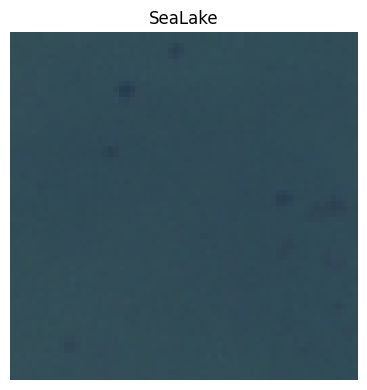

In [11]:
val_image, val_label = next(iter(val_loader))

print("Image shape:", val_image.shape)
print("Val label shape:", val_label.shape)

image_for_plot = val_image[0].permute(1, 2, 0)
class_name = class_names[val_label[0].item()]

plt.figure(figsize=(4, 4))
plt.imshow(image_for_plot)
plt.title(class_name)
plt.axis('off')
plt.tight_layout()
plt.show()

# 2. CNN-baseline

## 2.1 Сбор базовой CNN


Архитектура для входа [32, 3, 64, 64]:

| Блок  | Операции | Форма выхода |
| ----  | -------- | ------------ |
| 1 | `Conv2d(3, 16, 3, padding=1)` → ReLU() → MaxPool2d(2)  | [32, 16, 32,32] |
| 2 | `Conv2d(16, 32, 3, padding=1)` → ReLU() → MaxPool2d(2) | [32, 32, 16, 16]|
| 3 | `Conv2d(32, 64, 3, padding=1)` → ReLU() → MaxPool2d(2) | [32, 64, 8, 8]  |
| Усреднение | `nn.AdaptiveAvgPool((4, 4))`                  | [32, 64, 4, 4]  |
| Разворачивание | `Flatten()`                               | [32, 1024]      |
| Классификатор  | `Linear(1024, 10)`                        | [32, 10]        |

In [12]:
class GeoCNN(nn.Module):
  def __init__(self, num_classes=10):
    super().__init__()

    self.features = nn.Sequential(
        nn.Conv2d(
            in_channels=3,
            out_channels=16,
            kernel_size=3,
            padding=1,
        ),
        nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Conv2d(
            in_channels=16,
            out_channels=32,
            kernel_size=3,
            padding=1,
        ),
        nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            padding=1,
        ),
        nn.ReLU(),
        nn.MaxPool2d(2),

        nn.AdaptiveAvgPool2d((4, 4))
    )


    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(1024, num_classes)
    )

  def forward(self, x):
    x = self.features(x)
    return self.classifier(x)

In [13]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = GeoCNN(num_classes=len(class_names)).to(device)

images, labels = next(iter(val_loader))

loss_fn = nn.CrossEntropyLoss()


model.eval()

with torch.inference_mode():
  logits = model(images.to(device))

  loss = loss_fn(
      logits,
      labels.to(device)
  )

print("Logits shape:", logits.shape)
print("Loss before training:", loss.item())

parameter_count = sum(p.numel() for p in model.parameters())
print("Parameters:", parameter_count)

Logits shape: torch.Size([32, 10])
Loss before training: 2.2981982231140137
Parameters: 33834


Выбранные метрики качества:

  * Accuracy
  * Macro-F1
  * Top-3 accuracy


## 2.2 Функция валидации

In [14]:
def evaluate_metrics(
    model,
    dataloader,
    loss_fn,
    device,
    num_classes,
):

  model.eval()

  total_loss = 0.0
  total_correct = 0
  total_objects = 0
  total_top3_correct = 0

  all_labels = []
  all_predictions = []

  with torch.inference_mode():
    for images, labels in dataloader:
      images = images.to(device)
      labels = labels.to(device)

      logits = model(images)
      loss = loss_fn(logits, labels)

      predictions = logits.argmax(dim=1)
      top3 = logits.topk(k=3, dim=1).indices

      batch_size = labels.size(0)

      total_loss += loss.item() * batch_size
      total_correct += (predictions == labels).sum().item()
      total_top3_correct += (
          (top3 == labels.unsqueeze(1))
          .any(dim=1)
          .sum()
          .item()
      )
      total_objects += batch_size

      all_labels.extend(labels.cpu().tolist())
      all_predictions.extend(predictions.cpu().tolist())

  macro_f1 = f1_score(
      all_labels,
      all_predictions,
      labels=list(range(num_classes)),
      average='macro',
      zero_division=0,
  )

  return ({
      "loss": total_loss / total_objects,
      "accuracy": total_correct / total_objects,
      "macro_f1": macro_f1,
      "top3_accuracy": total_top3_correct /  total_objects,
  })

In [15]:
metrics = evaluate_metrics(
    model,
    val_loader,
    loss_fn,
    device,
    num_classes=len(class_names),
)

print(metrics)
print(f"Macro-F1: {metrics["macro_f1"]:.4f}")

{'loss': 2.301453545888265, 'accuracy': 0.10037037037037037, 'macro_f1': 0.02102468351077917, 'top3_accuracy': 0.33037037037037037}
Macro-F1: 0.0210


# 3. Training pipeline

### Первый обучающий эксперимент

**Настройки модели:**

| Настройка | Значение |
| --- | --- |
| Модель | Новый экземпляр `GeoCNN` |
| Оптимизатор | `Adam, lr=0.001` |
| Функция потерь | `nn.CrossEntropyLoss()` |
| Максимум эпох | 30 |
| Ранняя остановка | 3 эпохи без улучшения |
| Критерий лучшей модели | Максимальный validation macro-f1 |
| Файл | `checkpoints/geo_cnn_baseline.pth` |



*Функция обучения*:


In [16]:
def train_one_epoch(
    model,
    dataloader,
    loss_fn,
    optimizer,
    device,
):
  model.train()

  total_loss = 0.0
  total_correct = 0
  total_objects = 0

  for images, labels in dataloader:
    images = images.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()

    logits = model(images)
    loss = loss_fn(logits, labels)

    loss.backward()
    optimizer.step()

    batch_size = len(images)

    total_loss += loss.item() * batch_size
    total_correct += (
        logits.argmax(dim=1) == labels
    ).sum().item()
    total_objects += batch_size

  average_loss = total_loss / total_objects
  accuracy = total_correct / total_objects

  return average_loss, accuracy

*Обучение с сохранением и ранней остановкой*

In [17]:
seed_everything(RANDOM_SEED)

train_loader = make_train_loader(
    train_dataset,
    RANDOM_SEED
)

# Параметры обучения
max_epochs = 30
patience = 3

best_epoch = None
epochs_without_improvement = 0

# Ключевая метрика
best_f1_macro = -float("inf")

min_delta = 1e-4

# Путь для сохранения state_dict лучшей модели
checkpoint_path = Path("checkpoints/geo_cnn_baseline.pth")
checkpoint_path.parent.mkdir(parents=True, exist_ok=True)

model = GeoCNN(num_classes=len(class_names)).to(device)
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
)

history = []

for epoch in range(1, max_epochs+1):
  train_loss, train_accuracy = train_one_epoch(
      model,
      train_loader,
      loss_fn,
      optimizer,
      device,
  )

  metrics = evaluate_metrics(
      model,
      val_loader,
      loss_fn,
      device,
      num_classes=len(class_names),
  )

  history.append(
      {
          "epoch": epoch,
          "train_loss": train_loss,
          "train_accuracy": train_accuracy,
          "val_loss": metrics["loss"],
          "val_accuracy": metrics["accuracy"],
          "val_macro_f1": metrics["macro_f1"],
          "val_top3_accuracy": metrics["top3_accuracy"]
      }
  )

  macro_f1 = metrics["macro_f1"]

  if macro_f1 > best_f1_macro + min_delta:
    best_epoch = epoch
    best_f1_macro = macro_f1
    epochs_without_improvement = 0

    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "epoch": epoch,
            "metrics": metrics,
            "class_names": class_names
        },
        checkpoint_path
    )
    status = "saved"

  else:
    epochs_without_improvement += 1
    status = (
        f"no improvement"
        f"{epochs_without_improvement}/{patience}"
    )

  print(
      f"Epoch {epoch:2d}/{max_epochs} | "
      f"Train loss: {train_loss:.4f} | "
      f"Train accuracy: {train_accuracy:.4f} | "
      f"Val loss: {metrics['loss']:.4f} | "
      f"Val accuracy: {metrics['accuracy']:.4f} | "
      f"Val macro-f1: {metrics['macro_f1']:.4f} | "
      f"Val top3_accuracy: {metrics['top3_accuracy']:.4f} | "
      f"{status}"
  )

  if epochs_without_improvement >= patience:
    print("Early stopping")
    break

print(
    f"Best epoch {best_epoch} | "
    f"Best macro_f1: {best_f1_macro:.4f}"
)

Epoch  1/30 | Train loss: 1.3691 | Train accuracy: 0.4852 | Val loss: 1.0112 | Val accuracy: 0.6515 | Val macro-f1: 0.6371 | Val top3_accuracy: 0.9126 | saved
Epoch  2/30 | Train loss: 0.9284 | Train accuracy: 0.6661 | Val loss: 0.7682 | Val accuracy: 0.7533 | Val macro-f1: 0.7465 | Val top3_accuracy: 0.9456 | saved
Epoch  3/30 | Train loss: 0.7621 | Train accuracy: 0.7283 | Val loss: 0.8084 | Val accuracy: 0.7078 | Val macro-f1: 0.6988 | Val top3_accuracy: 0.9474 | no improvement1/3
Epoch  4/30 | Train loss: 0.6766 | Train accuracy: 0.7545 | Val loss: 0.7178 | Val accuracy: 0.7304 | Val macro-f1: 0.7200 | Val top3_accuracy: 0.9574 | no improvement2/3
Epoch  5/30 | Train loss: 0.6054 | Train accuracy: 0.7855 | Val loss: 0.6207 | Val accuracy: 0.7807 | Val macro-f1: 0.7755 | Val top3_accuracy: 0.9630 | saved
Epoch  6/30 | Train loss: 0.5849 | Train accuracy: 0.7919 | Val loss: 0.8146 | Val accuracy: 0.7200 | Val macro-f1: 0.7142 | Val top3_accuracy: 0.9452 | no improvement1/3
Epoch  7/3

*Проверка существующего результата*

In [18]:
checkpoint = torch.load(
    checkpoint_path,
    map_location=device,
    weights_only=True,
)

baseline_model = GeoCNN(
    num_classes=len(class_names)
).to(device)

baseline_model.load_state_dict(checkpoint['model_state_dict'])

baseline_metrics = evaluate_metrics(
    baseline_model,
    val_loader,
    loss_fn,
    device,
    num_classes=len(class_names)
)

print(
    f"Loaded epoch: {checkpoint['epoch']} \n"
    f"Val loss: {baseline_metrics['loss']:.4f} \n"
    f"Val accuracy: {baseline_metrics['accuracy']:.4f} \n"
    f"Val macro_f1: {baseline_metrics['macro_f1']:.4f} \n"
    f"Val top3_accuracy: {baseline_metrics['top3_accuracy']:.4f}"
)

Loaded epoch: 14 
Val loss: 0.3944 
Val accuracy: 0.8644 
Val macro_f1: 0.8594 
Val top3_accuracy: 0.9856


# 4. Анализ ошибок


*Матрица ошибок*

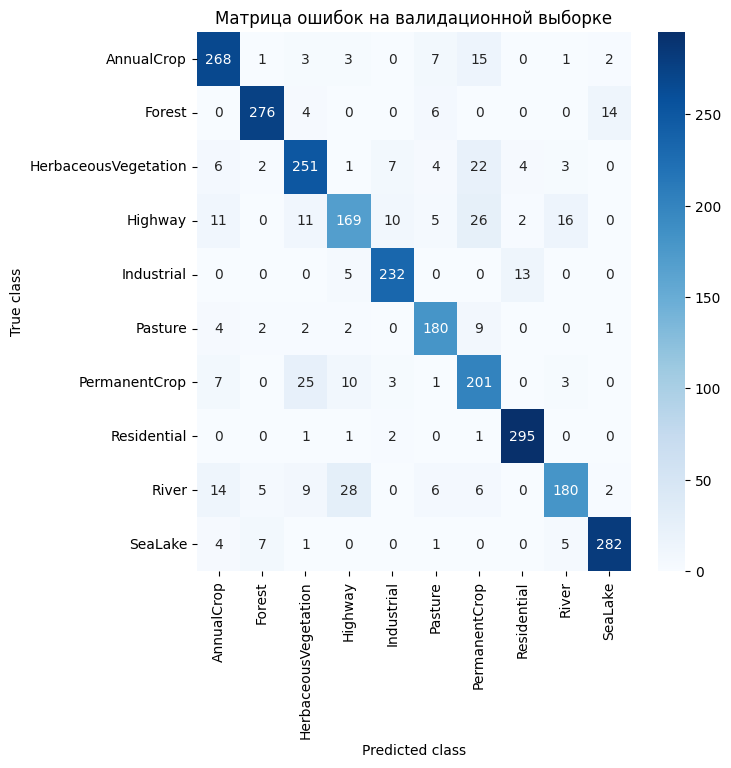

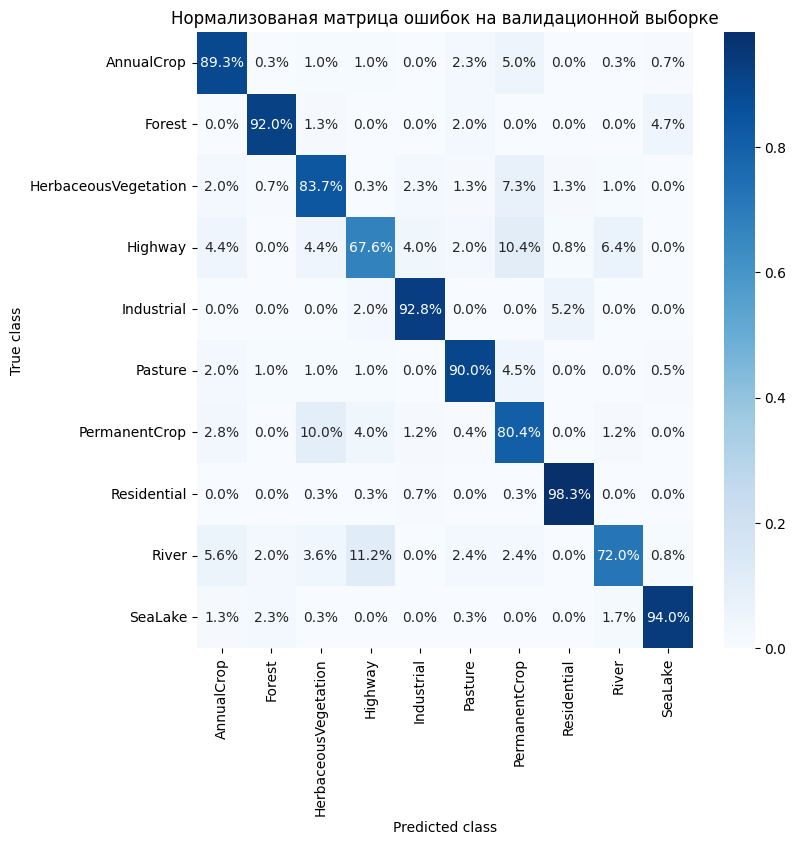

In [19]:
# Собираем все предсказания из батчей в списки
all_predictions = []
all_labels = []

baseline_model.eval()

with torch.inference_mode():
  for images, labels in val_loader:
    images = images.to(device)
    labels = labels.to(device)

    logits = baseline_model(images)
    predictions= logits.argmax(dim=1)

    all_predictions.extend(predictions.cpu().tolist())
    all_labels.extend(labels.cpu().tolist())


# Матрица ошибок
cm = confusion_matrix(
    all_labels,
    all_predictions,
    labels=list(range(len(class_names)))
)
plt.figure(figsize=(7, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.title("Матрица ошибок на валидационной выборке")
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.show()

# Нормализованная матрица ошибок
cm_normalized = confusion_matrix(
    all_labels,
    all_predictions,
    labels=list(range(len(class_names))),
    normalize="true",
)

plt.figure(figsize=(8, 8))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt='.1%',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.title("Нормализованая матрица ошибок на валидационной выборке")
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.show()

Наиболее проблемные классы:
| Predicted            | True                 |Количество ошибок | Доля ошибок |
| ---                  | ---                  | ---              | ---         |
| Highway              | River                | 28               | 11.2%       |
| PermanentCrop        | Highway              | 26               | 10.4%       |
| HerbaceousVegetation | PermanentCrop        | 25               | 10%         |
| PermanentCrop        | HerbaceousVegetation | 22               | 7.3%        |

Модель часто взаимно ошибается в классах `HerbaceousVegetation` и `PermanentCrop`, нужно дополнительно проверить насколько они реально похожи


**Некоторые изображения в которых модель ошиблась**

In [20]:
# индексы ошибок
errors_indexes = [i for i, (p, t) in enumerate(zip(all_predictions, all_labels)) if p != t]

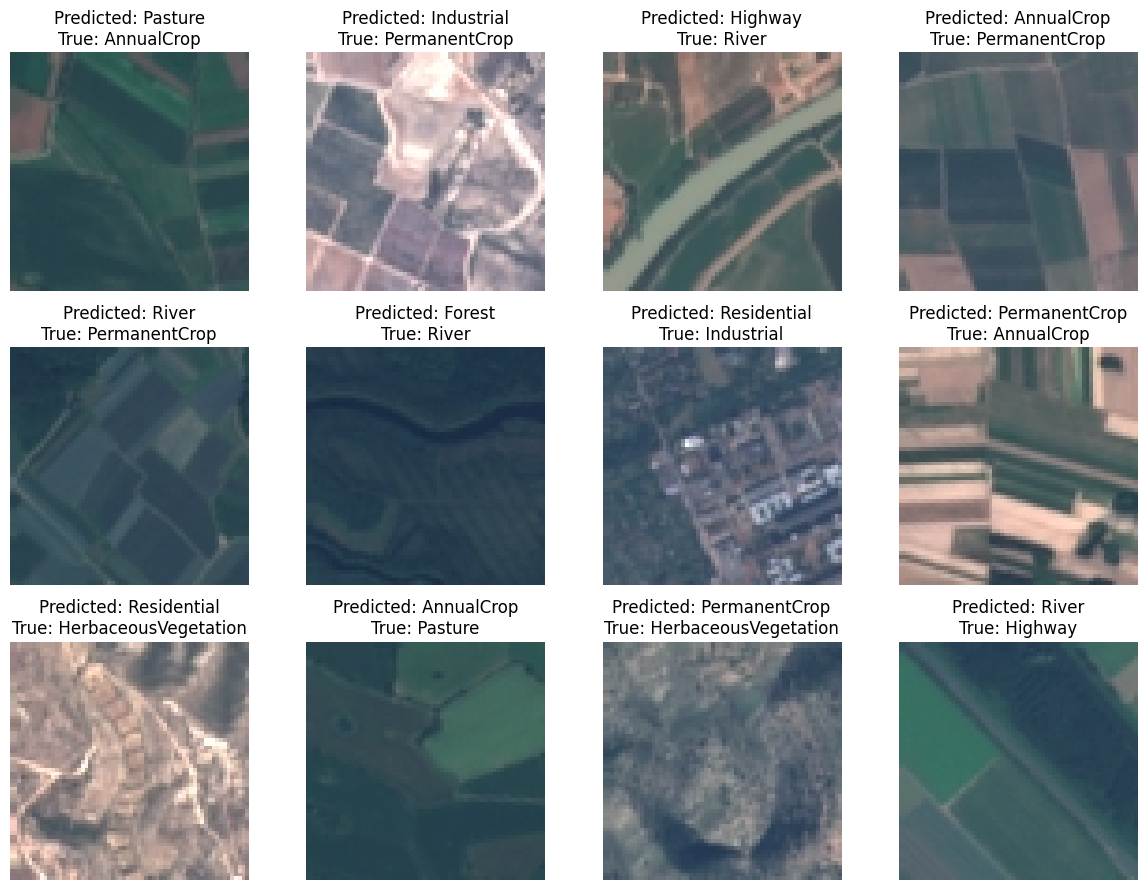

In [21]:
# 12 рандомных ошибок
random_12_index = random.Random(RANDOM_SEED).sample(errors_indexes, 12)

fig, axes = plt.subplots(3, 4, figsize=(12, 9))

for ax, index in zip(axes.flat, random_12_index):
  image, label = val_dataset[index]

  pred = class_names[all_predictions[index]]
  true = class_names[all_labels[index]]

  image_for_plot = image.permute(1, 2, 0)
  ax.imshow(image_for_plot)
  ax.set_title(f"Predicted: {pred}\nTrue: {true}")
  ax.axis('off')

plt.tight_layout()
plt.show()

In [22]:
highway_ind = class_names.index('Highway')
river_ind = class_names.index('River')
permanentcrop_ind = class_names.index('PermanentCrop')
herbaceous_ind = class_names.index('HerbaceousVegetation')


# Predicted: Highway; True: River
highway_river_idxs = [
    i for i in errors_indexes
    if all_predictions[i] == highway_ind
    and all_labels[i] == river_ind
]
highway_river_sample = random.Random(RANDOM_SEED).sample(
    highway_river_idxs,
    min(12, len(highway_river_idxs))
)

# Predicted: PermanentCrop; True: Highway
permanentcrop_highway_idxs = [
    i for i in errors_indexes
    if all_predictions[i] == permanentcrop_ind
    and all_labels[i] == highway_ind
]
permanentcrop_highway_sample = random.Random(RANDOM_SEED).sample(
    permanentcrop_highway_idxs,
    min(12, len(permanentcrop_highway_idxs))
)

# Predicted: HerbaceousVegetation; True: PermanentCrop
herbaceous_permanentcrop_idxs = [
    i for i in errors_indexes
    if all_predictions[i] == herbaceous_ind
    and all_labels[i] == permanentcrop_ind
]
herbaceous_permanentcrop_sample = random.Random(RANDOM_SEED).sample(
    herbaceous_permanentcrop_idxs,
    min(12, len(herbaceous_permanentcrop_idxs))
)

# Predicted: PermanentCrop; True: HerbaceousVegetation
permanentcrop_herbaceous_idxs = [
    i for i in errors_indexes
    if all_predictions[i] == permanentcrop_ind
    and all_labels[i] == herbaceous_ind
]
permanentcrop_herbaceous_sample = random.Random(RANDOM_SEED).sample(
    permanentcrop_herbaceous_idxs,
    min(12, len(permanentcrop_herbaceous_idxs))
)

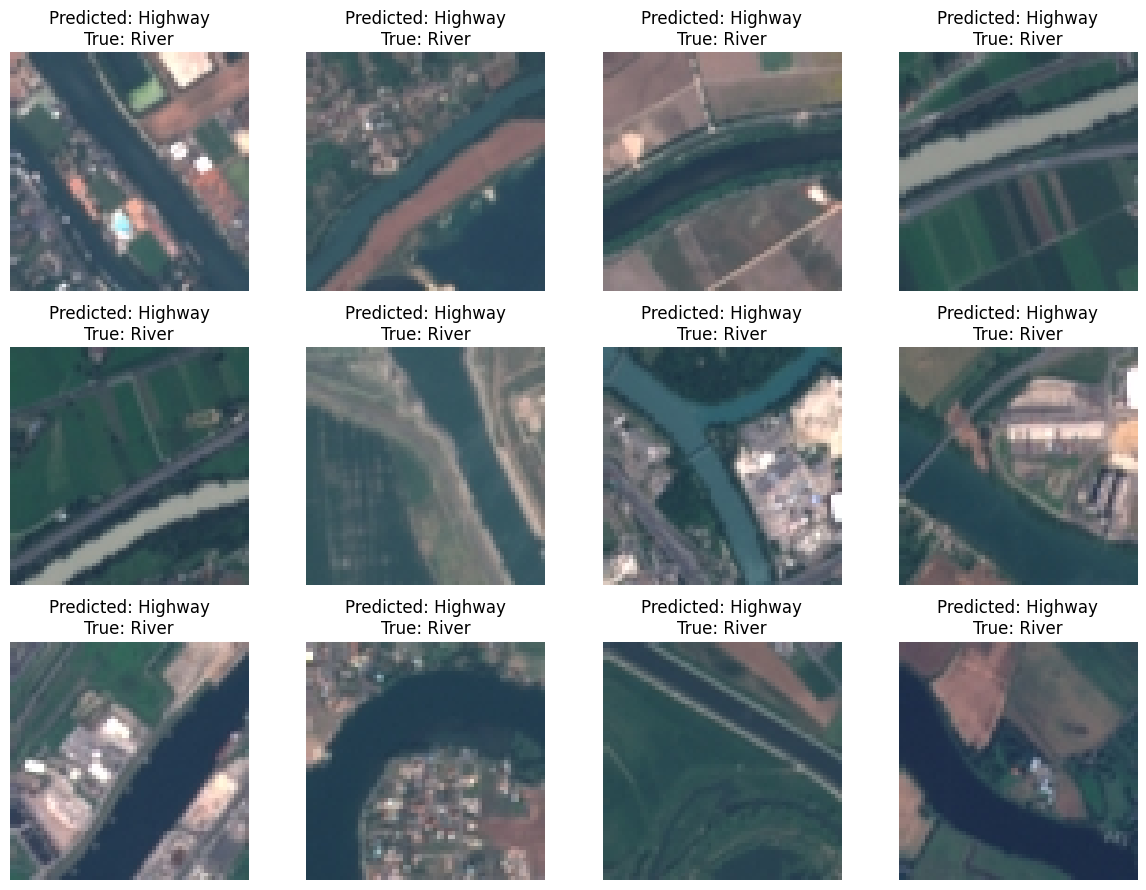

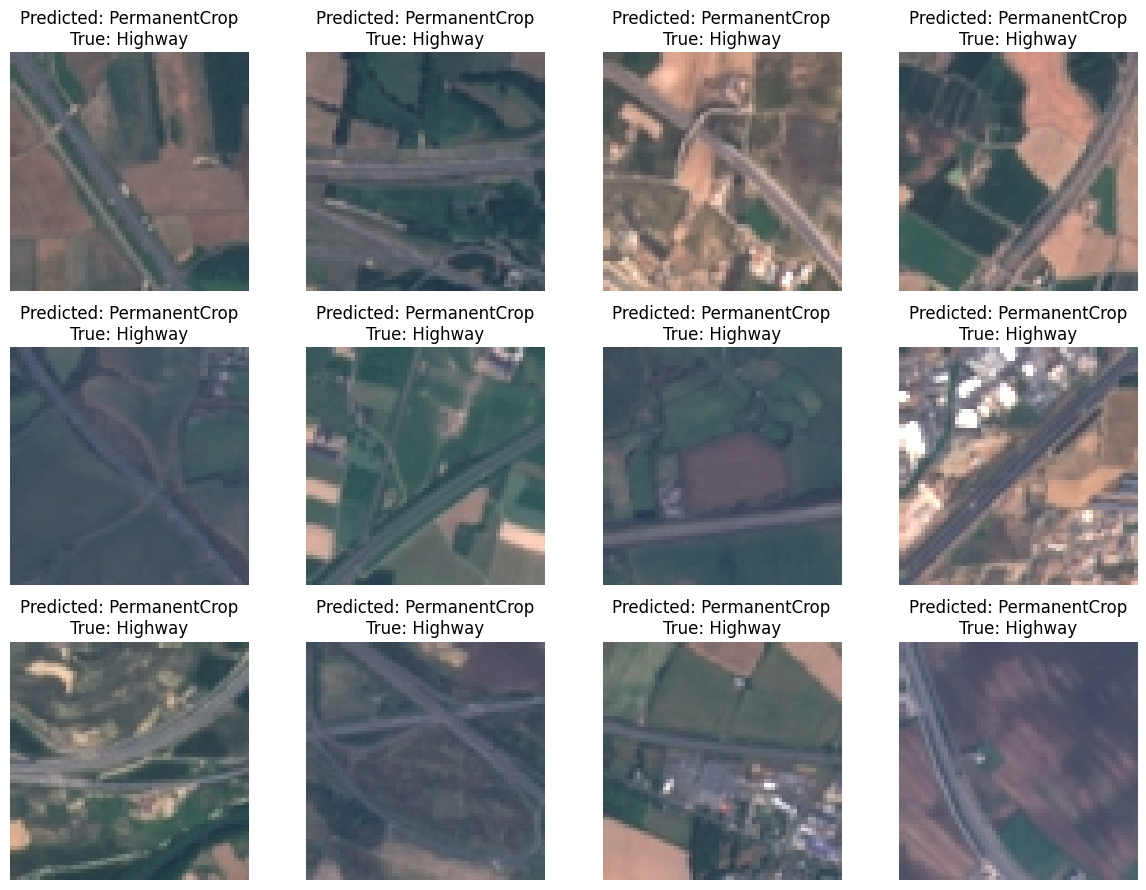

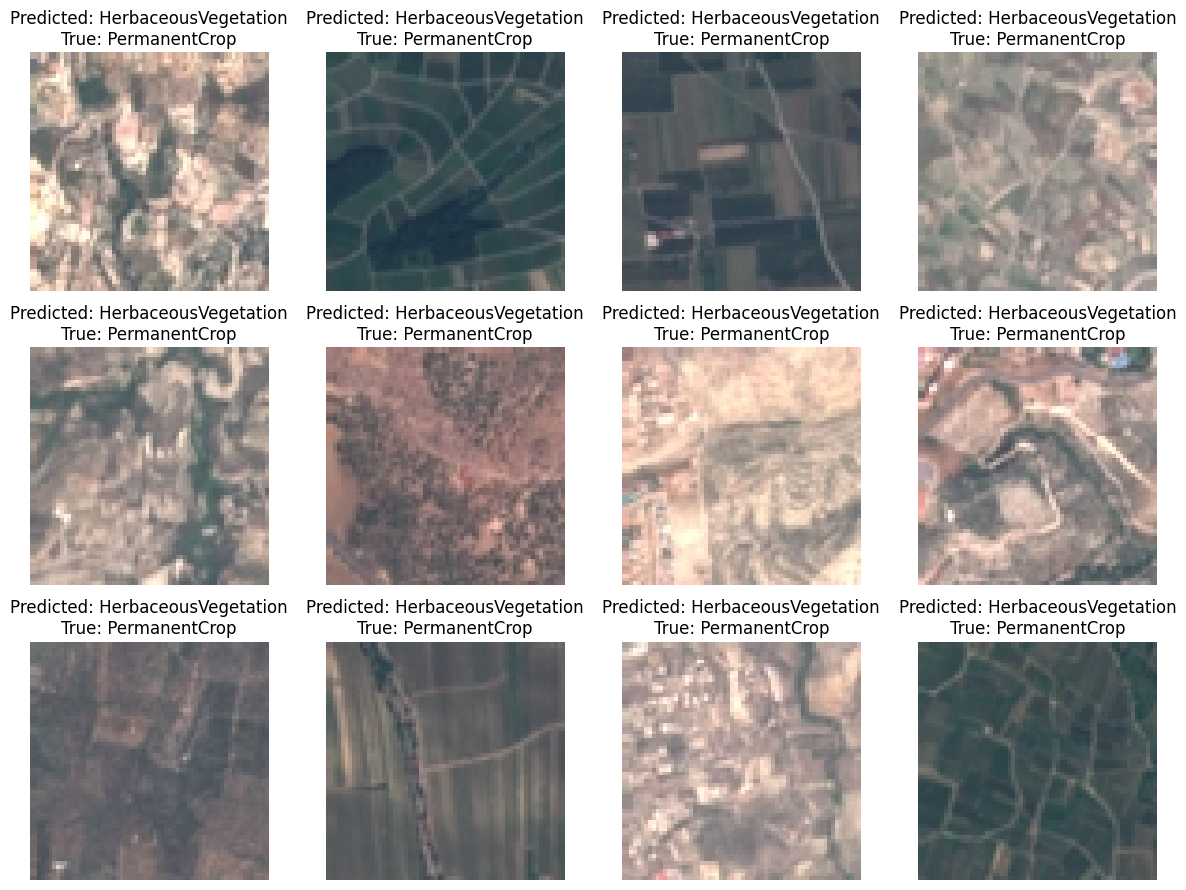

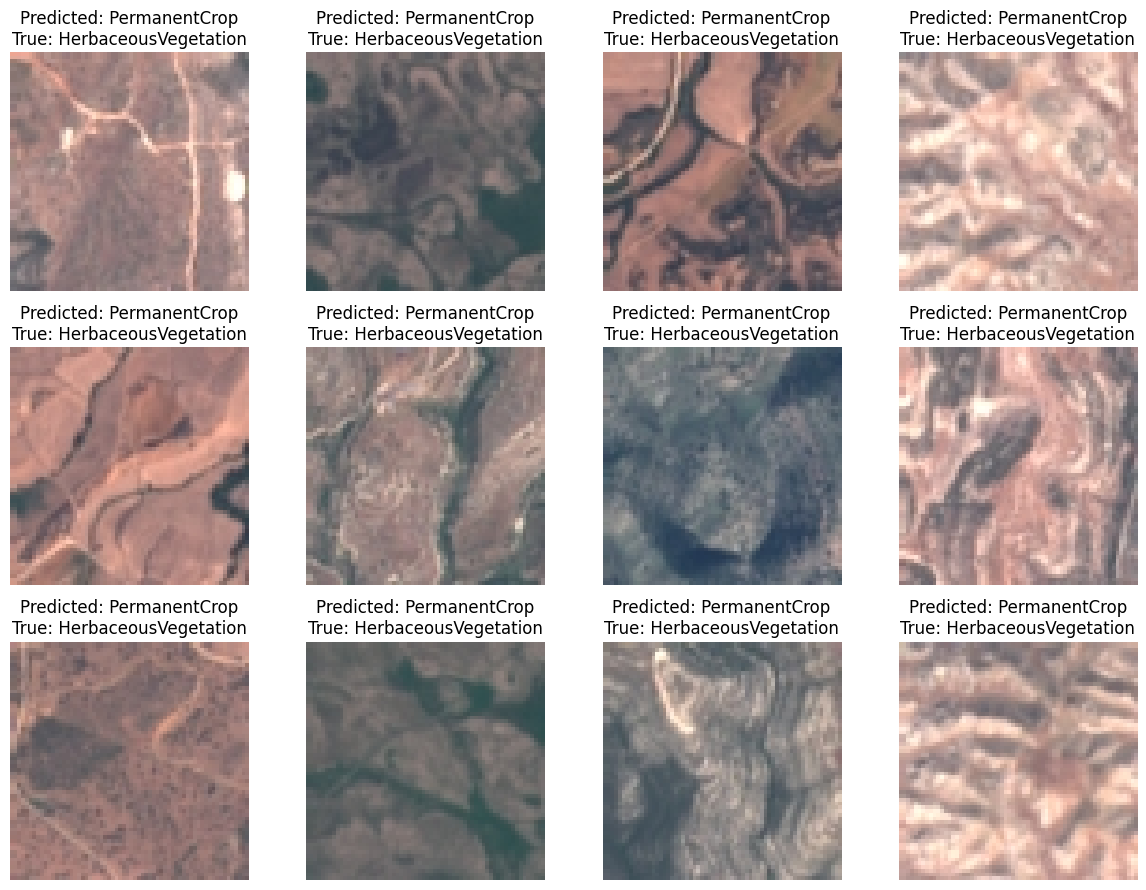

In [23]:
groups = [
    highway_river_sample,
    permanentcrop_highway_sample,
    herbaceous_permanentcrop_sample,
    permanentcrop_herbaceous_sample,
]

for group in groups:

  fig, axes = plt.subplots(3, 4, figsize=(12, 9))

  for ax, index in zip(axes.flat, group):
    image, label = val_dataset[index]

    pred = class_names[all_predictions[index]]
    true = class_names[all_labels[index]]

    image_for_plot = image.permute(1, 2, 0)
    ax.imshow(image_for_plot)
    ax.set_title(f"Predicted: {pred}\nTrue: {true}")
    ax.axis('off')

  plt.tight_layout()
  plt.show()

  print("\n")

**Выводы по анализу ошибок:**

Анализ ошибок показывает, что baseline CNN испытывает наибольшие трудности с классами Highway и River, а также с визуально близкими PermanentCrop и HerbaceousVegetation. В случае с Highway значительную часть занимают изображений часто занимают поля, что может объяснять ошибки в пользу PermanentCrop. River и Highway имеют схожую вытянутую геометрию. PermanentCrop и HerbaceousVegetation визуально близки даже при ручном просмотре

# 5. Исследовательские эксперименты


Таблица результатов:
| Experiment | Changes           | Val accuracy | Macro-F1 | Best epoch |
| ---        | ---               | ---          | ---      | ---        |
| Baseline   | ToTensor          | 0.8644       | 0.8594   | 14         |
| HFlip      | + horizontal flip | 0.8511       | 0.8466   | 14         |
| Normalize  | train mean/std    | 0.8585       | 0.8533   | 7          |

### HFlip experiment

In [24]:
train_transform_flip = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
])

aug_train_source = EuroSAT(
    root='data',
    transform=train_transform_flip,
    download=False,
)

aug_train_dataset = Subset(aug_train_source, train_indices.tolist())

aug_train_loader = make_train_loader(
    aug_train_dataset,
    RANDOM_SEED
)

Проверка батча

In [26]:
images, labels = next(iter(aug_train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Images dtype:", images.dtype)
print("Labels dtype:", labels.dtype)

Images shape: torch.Size([32, 3, 64, 64])
Labels shape: torch.Size([32])
Images dtype: torch.float32
Labels dtype: torch.int64


Повтроение эксперимента

In [27]:
seed_everything(RANDOM_SEED)

aug_train_loader = make_train_loader(
    aug_train_dataset,
    RANDOM_SEED
)

# Параметры обучения
max_epochs = 30
patience = 3

best_epoch = None
epochs_without_improvement = 0

# Ключевая метрика
best_f1_macro = -float('inf')

min_delta = 1e-4

# Путь для сохранения state_dict
aug_checkpoint_path = Path("checkpoints/aug_geo_cnn_baseline.pth")
aug_checkpoint_path.parent.mkdir(parents=True, exist_ok=True)

aug_model = GeoCNN(num_classes=len(class_names)).to(device)
aug_optimizer = torch.optim.Adam(
    aug_model.parameters(),
    lr=0.001,
)

aug_history = []

for epoch in range(1, max_epochs+1):
  train_loss, train_accuracy = train_one_epoch(
      aug_model,
      aug_train_loader,
      loss_fn,
      aug_optimizer,
      device,
  )

  metrics = evaluate_metrics(
      aug_model,
      val_loader,
      loss_fn,
      device,
      num_classes=len(class_names),
  )

  aug_history.append({
      "epoch": epoch,
      "train_loss": train_loss,
      "train_accuracy": train_accuracy,
      "val_loss": metrics['loss'],
      "val_accuracy": metrics['accuracy'],
      "val_macro_f1": metrics['macro_f1'],
      "val_top3_accuracy": metrics['top3_accuracy'],
  })

  macro_f1 = metrics['macro_f1']

  if macro_f1 > best_f1_macro + min_delta:
    best_f1_macro = macro_f1
    best_epoch = epoch
    epochs_without_improvement = 0

    torch.save(
        {
            "model_state_dict": aug_model.state_dict(),
            "epoch": epoch,
            "metrics": metrics,
            "class_names": class_names,
        },
        aug_checkpoint_path
    )

    status = 'save'

  else:
    epochs_without_improvement += 1
    status = (
        f"no improvement"
        f"{epochs_without_improvement}/{patience}"
    )

  print(
      f"Epoch {epoch:2d}/{max_epochs} | "
      f"Train loss: {train_loss:.4f} | "
      f"Train accuracy: {train_accuracy:.4f} | "
      f"Val loss: {metrics['loss']:.4f} | "
      f"Val accuracy: {metrics['accuracy']:.4f} | "
      f"Val macro-f1: {metrics['macro_f1']:.4f} | "
      f"Val top3_accuracy: {metrics['top3_accuracy']:.4f} | "
      f"{status}"
  )

  if epochs_without_improvement >= patience:
    print("Early stopping")
    break

print(
    f"Best epoch {best_epoch} | "
    f"Best macro_f1: {best_f1_macro:.4f}"
)

Epoch  1/30 | Train loss: 1.3919 | Train accuracy: 0.4753 | Val loss: 1.1011 | Val accuracy: 0.6226 | Val macro-f1: 0.6050 | Val top3_accuracy: 0.8889 | save
Epoch  2/30 | Train loss: 0.9767 | Train accuracy: 0.6450 | Val loss: 0.8250 | Val accuracy: 0.7281 | Val macro-f1: 0.7204 | Val top3_accuracy: 0.9381 | save
Epoch  3/30 | Train loss: 0.8115 | Train accuracy: 0.7080 | Val loss: 0.7591 | Val accuracy: 0.7341 | Val macro-f1: 0.7274 | Val top3_accuracy: 0.9563 | save
Epoch  4/30 | Train loss: 0.7152 | Train accuracy: 0.7419 | Val loss: 0.6146 | Val accuracy: 0.7852 | Val macro-f1: 0.7749 | Val top3_accuracy: 0.9678 | save
Epoch  5/30 | Train loss: 0.6510 | Train accuracy: 0.7678 | Val loss: 0.6715 | Val accuracy: 0.7615 | Val macro-f1: 0.7564 | Val top3_accuracy: 0.9641 | no improvement1/3
Epoch  6/30 | Train loss: 0.6130 | Train accuracy: 0.7822 | Val loss: 0.6970 | Val accuracy: 0.7496 | Val macro-f1: 0.7446 | Val top3_accuracy: 0.9633 | no improvement2/3
Epoch  7/30 | Train loss: 

### Normalize experiment

In [33]:
channels_sum = 0
channels_squared_sum = 0
num_batches = 0

for data, _ in train_loader:
  channels_sum += torch.mean(data, dim=[0, 2, 3])
  channels_squared_sum += torch.mean(data**0.5, dim=[0, 2, 3])
  num_batches += 1


train_mean = channels_sum / num_batches
train_std = (channels_squared_sum  / num_batches - train_mean**2)**0.5

In [45]:
train_transform_normalize = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=train_mean, std=train_std),
])

val_transform_normalize = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=train_mean, std=train_std),
])


normilize_train_source = EuroSAT(
    root='data',
    transform=train_transform_normalize,
    download=False,
)

normilize_val_source = EuroSAT(
    root='data',
    transform=val_transform_normalize,
    download=False,
)


normalize_train_dataset = Subset(normilize_train_source, train_indices.tolist())
normalize_val_dataset = Subset(normilize_val_source, val_indices.tolist())


normalize_train_loader = make_train_loader(
    normalize_train_dataset,
    RANDOM_SEED
)

normalize_val_loader = DataLoader(
    normalize_val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

Проверка батча

In [46]:
images, labels = next(iter(normalize_val_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Images dtype:", images.dtype)
print("Labels dtype:", labels.dtype)


Images shape: torch.Size([32, 3, 64, 64])
Labels shape: torch.Size([32])
Images dtype: torch.float32
Labels dtype: torch.int64


In [48]:
seed_everything(RANDOM_SEED)

normalize_train_loader = make_train_loader(
    normalize_train_dataset,
    RANDOM_SEED
)

# Параметры обучения
max_epochs = 30
patience = 3

best_epoch = None
epochs_without_improvement = 0

# Ключевая метрика
best_f1_macro = -float('inf')

min_delta = 1e-4

# Путь для сохранения state_dict
normalize_checkpoint_path = Path("checkpoints/normalize_geo_cnn_baseline.pth")
normalize_checkpoint_path.parent.mkdir(parents=True, exist_ok=True)

normalize_model = GeoCNN(num_classes=len(class_names)).to(device)
normalize_optimizer = torch.optim.Adam(
    normalize_model.parameters(),
    lr=0.001,
)

normialize_history = []

for epoch in range(1, max_epochs+1):
  train_loss, train_accuracy = train_one_epoch(
      normalize_model,
      normalize_train_loader,
      loss_fn,
      normalize_optimizer,
      device,
  )

  metrics = evaluate_metrics(
      normalize_model,
      normalize_val_loader,
      loss_fn,
      device,
      num_classes=len(class_names),
  )

  normialize_history.append({
      "epoch": epoch,
      "train_loss": train_loss,
      "train_accuracy": train_accuracy,
      "val_loss": metrics['loss'],
      "val_accuracy": metrics['accuracy'],
      "val_macro_f1": metrics['macro_f1'],
      "val_top3_accuracy": metrics['top3_accuracy'],
  })

  macro_f1 = metrics['macro_f1']

  if macro_f1 > best_f1_macro + min_delta:
    best_f1_macro = macro_f1
    best_epoch = epoch
    epochs_without_improvement = 0

    torch.save(
        {
            "model_state_dict": normalize_model.state_dict(),
            "epoch": epoch,
            "metrics": metrics,
            "class_names": class_names,
        },
        normalize_checkpoint_path
    )

    status = 'save'

  else:
    epochs_without_improvement += 1
    status = (
        f"no improvement"
        f"{epochs_without_improvement}/{patience}"
    )

  print(
      f"Epoch {epoch:2d}/{max_epochs} | "
      f"Train loss: {train_loss:.4f} | "
      f"Train accuracy: {train_accuracy:.4f} | "
      f"Val loss: {metrics['loss']:.4f} | "
      f"Val accuracy: {metrics['accuracy']:.4f} | "
      f"Val macro-f1: {metrics['macro_f1']:.4f} | "
      f"Val top3_accuracy: {metrics['top3_accuracy']:.4f} | "
      f"{status}"
  )

  if epochs_without_improvement >= patience:
    print("Early stopping")
    break

print(
    f"Best epoch {best_epoch} | "
    f"Best macro_f1: {best_f1_macro:.4f}"
)

Epoch  1/30 | Train loss: 1.1743 | Train accuracy: 0.5684 | Val loss: 0.8276 | Val accuracy: 0.7133 | Val macro-f1: 0.7079 | Val top3_accuracy: 0.9348 | save
Epoch  2/30 | Train loss: 0.7064 | Train accuracy: 0.7470 | Val loss: 0.6529 | Val accuracy: 0.7826 | Val macro-f1: 0.7777 | Val top3_accuracy: 0.9600 | save
Epoch  3/30 | Train loss: 0.6095 | Train accuracy: 0.7824 | Val loss: 0.6224 | Val accuracy: 0.7819 | Val macro-f1: 0.7752 | Val top3_accuracy: 0.9659 | no improvement1/3
Epoch  4/30 | Train loss: 0.5355 | Train accuracy: 0.8083 | Val loss: 0.5502 | Val accuracy: 0.8107 | Val macro-f1: 0.8031 | Val top3_accuracy: 0.9759 | save
Epoch  5/30 | Train loss: 0.4989 | Train accuracy: 0.8278 | Val loss: 0.5143 | Val accuracy: 0.8233 | Val macro-f1: 0.8171 | Val top3_accuracy: 0.9781 | save
Epoch  6/30 | Train loss: 0.4691 | Train accuracy: 0.8346 | Val loss: 0.5337 | Val accuracy: 0.8111 | Val macro-f1: 0.8075 | Val top3_accuracy: 0.9726 | no improvement1/3
Epoch  7/30 | Train loss: 